# 310.2. Photo-z analysis

<div style="max-width:300px; float: left; margin-right: 1em">

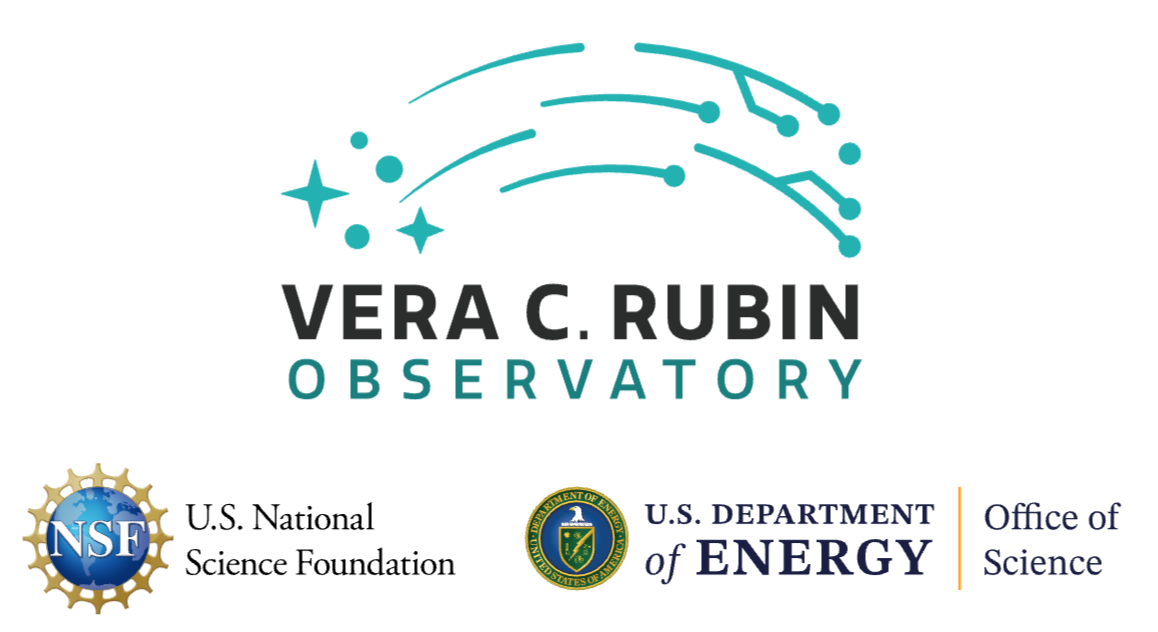

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 2](https://dp2.lsst.io)\
Container Size: Large\
LSST Science Pipelines version: v30.0.11\
Last verified to run: 2026-09-02\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** Understand and apply the photo-z errors in analyses.

**LSST data products:** LSDB `object_photoz` table

**Packages:** `lsdb`

**Credit:** Originally developed by the Rubin Community Science team with Bryce Kalmbach. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

Photometric redshift (photo-z) estimates for Data Preview 2 were generated by the Rubin Commissioning Photo-z Science Unit and are available as [LSDB](https://docs.lsdb.io/)-formatted files, as documented in "Photometric Redshifts for Data Preview 2" ([RTN-124](https://rtn-124.lsst.io/)).

**Algorithms:**
 * `bpz`: Bayesian Photometric Redshifts (BPZ; [Benítez 2000](http://arxiv.org/abs/astro-ph/9811189))
 * `dnf`: Directional Neighbourhood Fitting (DNF; [De Vicente et al. 2016](http://arxiv.org/abs/1511.07623))
 * `fzboost`: FlexZBoost ([Izbicki & Lee 2017](https://doi.org/10.1214/17-EJS1302))
 * `gpz`: Gaussian processes for photometric redshifts (GPz; [Almosallam et al. 2016](http://doi.org/10.1093/mnras/stw1618))
 * `knn`: k-Nearest Neighbors (kNN; [The RAIL Team et al. 2025](https://arxiv.org/abs/2505.02928))
 * `tpz`: Trees for Photo-Z ([Carrasco Kind & Brunner 2013](https://academic.oup.com/mnras/article/432/2/1483/1029454))

**Measurements:** For each algorithm these tables carry four point estimates, `z_best`, `z_mode`, `z_mean`, and `z_median` plus $1\sigma$ and $2\sigma$ credible intervals (`z_err68_low`/`high`, `z_err95_low`/`high`). 

 * `z_best`: Minimal risk point estimate described in Section 4.2 of [Tanaka et al. 2018](https://arxiv.org/abs/1704.05988) with $\gamma = 0.15$
 * `z_mode`, `z_mean`, and `z_median`: point-estimates based on statistics derived from the posterior distribution function (PDF)
 * `z_err68_low`/`high`, `z_err95_low`/`high`: the $1\sigma$ and $2\sigma$ credible intervals derived from the PDF

**Caveats:** These estimates and their error bars are only very lightly validated.
Treat them as provisional and use the results with caution.

**Guidance and recommendations:** This tutorial characterizes the photo-z and their errors through a series of data visualizations, in order to help guide scientific analyses that incorporate the photo-z.
At this time, there are no flag values or strict, quantitative guidance to assist users in understanding photo-z estimate quality and deciding when a photo-z is "good enough", and that ultimately depends on the needs of the analysis.
Providing photo-z flags is a work in progress.

For scientific analyses that use the photo-z, it is recommended to:
 * use the results of more than one estimator, as they can differ (Section 3.1)
 * use the photo-z errors, as the errors can be large (Section 3.1)
 * consider the photometry (fluxes and errors), as uncertain photometry leads to uncertain photo-z (Sections 3.2 and 4)

\
**Related tutorials:** The 100-level tutorial on catalog access (for LSDB and TAP) and the Butler.

### 1.1. Import packages

Import the `lsdb` package and a variety of other LSST, astronomy, and data visualization modules.

In [ ]:
import lsdb
from dask.distributed import Client
from lsst.daf.butler import Butler
from lsst.rsp import RSPDiscovery
from bokeh.io import output_notebook
from tqdm import tqdm
import holoviews as hv
from holoviews.operation.datashader import datashade, dynspread
import matplotlib.pyplot as plt
import numpy as np
import healsparse as hsp
import hpgeom as hpg
import skyproj
from datetime import datetime
import logging
import warnings
import os
import gc

### 1.2. Define parameters and functions

It is [recommended by the LSDB developers to use a Dask client](https://docs.lsdb.io/en/latest/tutorials/pre_executed/rubin_dp2.html#1.2-Create-a-Dask-client) when accessing the LSDB data sets.
Establish the client as per the guidance.

In [ ]:
client = Client(
    n_workers=4,
    threads_per_worker=1,
    memory_limit="auto",
    local_directory=f"/deleted-sundays/{os.environ.get('USER', 'dask_scratch')}",
)
print(f"Dask dashboard: {client.dashboard_link}")

Quiet down the output of the client going forward by suppressing all logging output except warnings.

In [ ]:
logging.getLogger("distributed").setLevel(logging.WARNING)

Instantiate the Butler and TAP services.

In [ ]:
butler = Butler('dp2', collections='dp2')

In [ ]:
discovery = RSPDiscovery("dp2")
tap_service = discovery.get_tap_client()

Set up for interactive plotting with `holoviews`. Order is important here: the `output_notebook()` command must be run after the `hv.extension('bokeh')` command or plots will not display.

In [ ]:
hv.extension('bokeh')

In [ ]:
output_notebook()

## 2. Retrieve a dataset

### 2.1. Load photo-z in a small region

Load the photo-z for objects within a 2 degree radius of random central coordinates within the DP2 WFD-region.

In [ ]:
ra_cen = 310.0
dec_cen = -20.0
radius = 2.0

All columns (aside from the coordinates, `ra` and `dec`, and the identifier `objectId`) are named as `<algorithm>_z_<measurement>`.

Choose to return only the "best" and $1\sigma$ error intervals for the FlexZBoost and BPZ algorithms, as examples.
In [RTN-124](https://rtn-124.lsst.io/) these two algorithms were identified as the most and least performant with DP2, respectively (see their Fig 10).

In [ ]:
pz_cat = lsdb.open_catalog(
    "/rubin/lsdb_data/dp2/object_photoz",
    search_filter=lsdb.ConeSearch(ra=ra_cen, dec=dec_cen, radius_arcsec=radius * 3600),
    columns=["objectId", "ra", "dec",
             "fzboost_z_best", "fzboost_z_err68_low", "fzboost_z_err68_high",
             "bpz_z_best", "bpz_z_err68_low", "bpz_z_err68_high"],
)

Option to display the lazily-loaded table.

In [ ]:
# pz_cat

Choose to limit this exploration to photo-z results between 0.1 and 3.0, the range over which the LSST was designed to optimize photo-z estimates (the LSST System Science Requirements Document, [LPM-17](https://docushare.lsst.org/docushare/dsweb/Get/LPM-17)).

In [ ]:
z1 = "0.01"
z2 = "3.0"
query = """fzboost_z_best > {} and fzboost_z_best < {} and bpz_z_best > {} and bpz_z_best < {}
        """.format(z1, z2, z1, z2)
pz_cat_zlim = pz_cat.query(query)

### 2.2. Load photometry and join

Load the LSDB-formatted `Object` table, and retrieve the Gaap (Gaussian Aperture) fluxes with a 1 pixel aperture, and their errors.
As described in [RTN-124](https://rtn-124.lsst.io/), the Gaap 1-pixel photometry were used as inputs to the photo-z algorithms.

In [ ]:
obj_cat = lsdb.open_catalog(
    "/rubin/lsdb_data/dp2/object_collection",
    search_filter=lsdb.ConeSearch(ra=ra_cen, dec=dec_cen, radius_arcsec=radius * 3600),
    columns=["objectId", "coord_ra", "coord_dec",
             "u_gaap1p0Flux", "g_gaap1p0Flux", "r_gaap1p0Flux",
             "i_gaap1p0Flux", "z_gaap1p0Flux", "y_gaap1p0Flux",
             "u_gaap1p0FluxErr", "g_gaap1p0FluxErr", "r_gaap1p0FluxErr",
             "i_gaap1p0FluxErr", "z_gaap1p0FluxErr", "y_gaap1p0FluxErr"])

Option to display the lazily-loaded table.

In [ ]:
# obj_cat

Join the photo-z and object photometry tables together.

In [ ]:
join_table = pz_cat_zlim.join(obj_cat, left_on="objectId", right_on="objectId",
                              suffixes=('', '_obj'), suffix_method="overlapping_columns")

In [ ]:
# join_table

### 2.3. Add photo-z error columns

Follow the [LSDB instructions for generating new columns](https://docs.lsdb.io/en/latest/tutorials/pre_executed/map_partitions.html#2.-Generating-New-Columns) to add _approximate_ errors from the $1\sigma$ intervals. 

> **Notice:** The intervals are not necessarily symmetric, and using this error value as, e.g., $z \pm \delta$, would be inappropriate. The `z_err68` columns are only used in this tutorial to represent the size of the error. In analyses, use the low and high values as reported in the photo-z table.

Also calculate the absolute value of the difference between the BPZ and FlexZBoost redshift estimates: $\Delta = |z1 - z2|$.

In [ ]:
def pz_err68(df, pixel):
    df["fzboost_z_err68"] = 0.5 * (df["fzboost_z_err68_high"] - df["fzboost_z_err68_low"])
    df["bpz_z_err68"] = 0.5 * (df["bpz_z_err68_high"] - df["bpz_z_err68_low"])
    df["abs_diff_zbest"] = np.abs(df["bpz_z_best"] - df["fzboost_z_best"])
    return df

Apply the `pz_err68` function.

In [ ]:
unrealized = join_table.map_partitions(pz_err68, include_pixel=True)
unrealized

Compute the values for the entire table.

In [ ]:
result = unrealized.compute()

View the first five rows of the table.

In [ ]:
result.head(5)

Restart client workers to free up memory.

In [ ]:
client.restart()

Delete what won't be used in the next section.

In [ ]:
del pz_cat, pz_cat_zlim, obj_cat
del join_table, unrealized
gc.collect()

## 3. Explore photo-z error relations

### 3.1. Between algorithms

To visualize and characterize the photo-z values and their errors, create a few interactive plots.

Define a function to make all the plots with the same design.

In [ ]:
def make_z_dyn_plot(col1, col2, data, x1x2=(0, 3), y1y2=(0, 3)):
    """
    Create a datashader plot.

    Parameters
    ----------
    col1, col2: string
        The x and y axes columns.
    data: dataframe
        The dataframe containing the columns.
    x1x2, y1y2 : tuple
        The x- and y-axis limits

    Returns
    -------
    p, bounds: DynamicMap
        Generate the plot with `p * bounds`.
    """

    w = int(600)
    h = int(np.floor(w * y1y2[1] / x1x2[1]))
    if h > w:
        h = w
    points = hv.Points((data[col1], data[col2]))
    boundsxy = (0, 0, 0, 0)
    box = hv.streams.BoundsXY(source=points, bounds=boundsxy)
    bounds = hv.DynamicMap(lambda bounds: hv.Bounds(bounds), streams=[box])
    p = dynspread(datashade(points, cmap="Viridis"))
    p = p.opts(width=w, height=h, padding=0.05, show_grid=True,
               xlim=x1x2, ylim=y1y2, xlabel=col1, ylabel=col2,
               tools=['box_select'])
    return p, bounds

Plot the FlexZBoost vs. the BPZ best redshift estimates.

In [ ]:
p, bounds = make_z_dyn_plot("fzboost_z_best", "bpz_z_best", result)
p * bounds

>**Figure 1:** For all objects in the retrieved subsample, the FlexZBoost vs. the BPZ "best" photo-z point estimates. This plot shows a general locus of agreement along x=y, but also many clumps of differing results. Notice that the FlexZBoost estimates show a more narrow quantization in the off-locus regions, where as the BPZ clumps are broader.

\
\
Plot the FlexZBoost vs. the BPZ best redshift $1\sigma$ error estimates.

In [ ]:
p, bounds = make_z_dyn_plot("fzboost_z_err68", "bpz_z_err68", result, y1y2=(0, 1.5))
p * bounds

>**Figure 2:** For all objects in the retrieved subsample, the FlexZBoost vs. the BPZ $1\sigma$ error estimates. This plot shows that the errors for BPZ are quite different from those of FlexZBoost. The BPZ errors appear to have an upper limit, for example, and the the FlexZBoost errors exhibit more narrow quantization. Most notably, there does not appear to be much of a locus along x=y beyond $\delta z \sim 0.3$; the two algorithms do not agree on the error in the photo-z estimates.

\
\
A natural expectation is that the photo-z errors are larger for objects with very different photo-z estimates from the two algorithms.
Make a few plots to characterize whether this is the case.

Plot the difference between the BPZ and FlexZBoost redshift estimates vs. the BPZ $1\sigma$ error.

In [ ]:
p, bounds = make_z_dyn_plot("abs_diff_zbest", "bpz_z_err68", result, y1y2=(0, 1.5))
p * bounds

>**Figure 3:** For all objects in the retrieved subsample, the absolute difference between the BPZ and FlexZBoost point estimates vs. the BPZ $1\sigma$ error. Whereas the expectation is that objects with very different photo-z from different estimators (large x-value) would also have larger photo-z errors (large y-values), this plot does not show a very strong correlation along x=y. This indicates that at least some uncertainty in the photo-z estimates is not represented in the error intervals.

\
\
Same as above, but use the FlexZBoost error values.

In [ ]:
p, bounds = make_z_dyn_plot("abs_diff_zbest", "fzboost_z_err68", result, y1y2=(0, 3))
p * bounds

>**Figure 4:** Similar to Figure 3, but vs. the FlexZBoost $1\sigma$ error. This plot also shows a weaker-than-expected correlation between the estimated error and the uncertainty between algorithms.

### 3.2. With photometry 

To visualize and characterize the photo-z values and their errors, together with the photometry from which the photo-z were derived, create a few interactive plots.

Plot the $i$-band vs. the $g$-band magnitudes, to get a sense of the values.


> **Warning:** The following cell produces a pink RuntimeWarning error message due to failures when attempting to convert negative forced fluxes to magnitudes. Forced fluxes are measured on sky-subtracted images regardless of whether the object has any detectable flux in the image, so forced fluxes can be slightly negative due to small fluctuations in the background. Negative fluxes cannot be converted to magnitudes, and will be omitted from the plot. For this particular demonstration that is ok, but analyses in which non-detections are meaningful or need to be accounted for should take care when converting forced fluxes to magnitudes.

In [ ]:
xvals = -2.5 * np.log10(result["i_gaap1p0Flux"]) + 31.4
yvals = -2.5 * np.log10(result["g_gaap1p0Flux"]) + 31.4
xlabel = "i-band Gaap Mag (forced)"
ylabel = "g-band Gaap Mag (forced)"
points = hv.Points((xvals, yvals))
boundsxy = (0, 0, 0, 0)
box = hv.streams.BoundsXY(source=points, bounds=boundsxy)
bounds = hv.DynamicMap(lambda bounds: hv.Bounds(bounds), streams=[box])
p = dynspread(datashade(points, cmap="Viridis"))
p = p.opts(width=400, height=400, padding=0.05, show_grid=True,
           xlim=(16, 30), ylim=(16, 30), xlabel=xlabel, ylabel=ylabel, tools=['box_select'])
p * bounds

>**Figure 5:** The $i$-band vs. $g$-band magnitudes. Notice that with forced photometry, magnitudes can be very faint (fainter than the detection threshold of the images, which is $\sim24$ mag around the selected coordinates, as will be shown in Section 4).

\
\
Now that the `RuntimeWarning` is understood, it is ok to ignore it for the rest of this tutorial.

In [ ]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

Plot the magnitude vs. its error, for the $i$-band, also to get a sense of the values.

In [ ]:
xvals = -2.5 * np.log10(result["i_gaap1p0Flux"]) + 31.4
yvals = xvals - (-2.5 * np.log10(result["i_gaap1p0Flux"]+result["i_gaap1p0FluxErr"]) + 31.4)
xlabel = "i-band Gaap Mag (forced)"
ylabel = "i-band Gaap Mag Error"
points = hv.Points((xvals, yvals))
boundsxy = (0, 0, 0, 0)
box = hv.streams.BoundsXY(source=points, bounds=boundsxy)
bounds = hv.DynamicMap(lambda bounds: hv.Bounds(bounds), streams=[box])
p = dynspread(datashade(points, cmap="Viridis"))
p = p.opts(width=600, height=300, padding=0.05, show_grid=True,
           xlim=(16, 30), ylim=(0, 3), xlabel=xlabel, ylabel=ylabel, tools=['box_select'])
p * bounds

>**Figure 6:** The $i$-band magnitude vs. its error. Objects detected with a signal-to-noise ratio of 5 will have an uncertainty of $\delta m \sim 0.24$ mag, and this is at $\sim 24$ mag in this plot. But notice that with forced photometry, the magnitude errors can be quite large for faint (undetected) objects.

\
\
Plot the $i$-band magnitude error vs. the FlexZBoost photo-z error.

In [ ]:
mags = -2.5 * np.log10(result["i_gaap1p0Flux"]) + 31.4
xvals = mags - (-2.5 * np.log10(result["i_gaap1p0Flux"]+result["i_gaap1p0FluxErr"]) + 31.4)
yvals = result["fzboost_z_err68"]
xlabel = "i-band Gaap Mag Error"
ylabel = "FlexZBoost Photo-z Error"
points = hv.Points((xvals, yvals))
boundsxy = (0, 0, 0, 0)
box = hv.streams.BoundsXY(source=points, bounds=boundsxy)
bounds = hv.DynamicMap(lambda bounds: hv.Bounds(bounds), streams=[box])
p = dynspread(datashade(points, cmap="Viridis"))
p = p.opts(width=600, height=300, padding=0.05, show_grid=True,
           xlim=(0, 0.5), ylim=(0, 2), xlabel=xlabel, ylabel=ylabel, tools=['box_select'])
p * bounds

>**Figure 7:** The $i$-band magnitude error vs. the FlexZBoost photo-z error. This plot shows the correlation: larger photometry errors yield larger photo-z errors.

\
\
Similar to the above plot, but with the BPZ photo-z error.

In [ ]:
mags = -2.5 * np.log10(result["i_gaap1p0Flux"]) + 31.4
xvals = mags - (-2.5 * np.log10(result["i_gaap1p0Flux"]+result["i_gaap1p0FluxErr"]) + 31.4)
yvals = result["bpz_z_err68"]
xlabel = "i-band Gaap Mag Error"
ylabel = "BPZ Photo-z Error"
points = hv.Points((xvals, yvals))
boundsxy = (0, 0, 0, 0)
box = hv.streams.BoundsXY(source=points, bounds=boundsxy)
bounds = hv.DynamicMap(lambda bounds: hv.Bounds(bounds), streams=[box])
p = dynspread(datashade(points, cmap="Viridis"))
p = p.opts(width=600, height=300, padding=0.05, show_grid=True,
           xlim=(0, 1), ylim=(0, 1.5), xlabel=xlabel, ylabel=ylabel, tools=['box_select'])
p * bounds

>**Figure 8:** Similar to Fig 7, but with the BPZ photo-z error, also showing how larger photometry errors yield larger photo-z errors.

\
\
Photometric redshift estimates are based on the object colors, and in some regions of color-space the relationship is less well-constrained. Explore this with a plot of the $g$-$i$ color vs. the BPZ photo-z error.

In [ ]:
band1 = "g"
band2 = "i"
mags1 = -2.5 * np.log10(result[band1 + "_gaap1p0Flux"]) + 31.4
mags2 = -2.5 * np.log10(result[band2 + "_gaap1p0Flux"]) + 31.4
xvals = mags1 - mags2
yvals = result["bpz_z_err68"]
xlabel = band1 + "-" + band2 + " Gaap color (forced)"
ylabel = "BPZ Photo-z Error"
points = hv.Points((xvals, yvals))
boundsxy = (0, 0, 0, 0)
box = hv.streams.BoundsXY(source=points, bounds=boundsxy)
bounds = hv.DynamicMap(lambda bounds: hv.Bounds(bounds), streams=[box])
p = dynspread(datashade(points, cmap="Viridis"))
p = p.opts(width=600, height=300, padding=0.05, show_grid=True,
           xlim=(-4, 5), ylim=(0, 1.5), xlabel=xlabel, ylabel=ylabel, tools=['box_select'])
p * bounds

>**Figure 9:** The $g$-$i$ Gaap color vs. the BPZ photo-z error. This plot shows the relationship beween galaxy color and photo-z error.

\
\
Delete what won't been needed in Section 4.

In [ ]:
del p, bounds
del result
gc.collect()

## 4. Explore photo-z spatial variation

As demonstrated above, the photometric quaily -- the brightness of the object, the depth of the deep coadd images, and the number of filters in which forced fluxes are measured -- affect the photo-z quality.

For Data Preview 2, the number of filters and image depth is not uniform across the surved area (see the maps on, e.g., the [observatons page](https://dp2.lsst.io/overview/observations.html)).

This section creates sky maps of the photo-z error and the photometric depth, and compares them.

### 4.1. Load photo-z in a larger region

Similar to Section 2.1., but with a larger radius so that the maps cover a larger region of sky.

In [ ]:
ra_cen = 310.0
dec_cen = -20.0
radius = 20.0

For this section, only use the FlexZBoost redshifts.

In [ ]:
pz_cat = lsdb.open_catalog(
    "/rubin/lsdb_data/dp2/object_photoz",
    search_filter=lsdb.ConeSearch(ra=ra_cen, dec=dec_cen,
                                  radius_arcsec=radius * 3600),
    columns=["objectId", "ra", "dec", "fzboost_z_best",
             "fzboost_z_err68_low", "fzboost_z_err68_high"],
)

As before, limit to redshifts 0.01 - 3.0 and calculate the _approximate_ error, then compute the full table.

In [ ]:
z1 = "0.01"
z2 = "3.0"
query = """fzboost_z_best > {} and fzboost_z_best < {}
        """.format(z1, z2)
pz_cat_zlim = pz_cat.query(query)

In [ ]:
def pz_err68_v2(df, pixel):
    df["fzboost_z_err68"] = 0.5 * (df["fzboost_z_err68_high"] - df["fzboost_z_err68_low"])
    return df

In [ ]:
unrealized = pz_cat_zlim.map_partitions(pz_err68_v2, include_pixel=True)
unrealized

In [ ]:
result = unrealized.compute()

### 4.2. Plot the sky map of photo-z error

Set up a HealSparse map with relatively low resolution that covers the sky region over which photo-z were returned.

In [ ]:
nside_coverage = 8
nside_sparse = 64
hspmap = hsp.HealSparseMap.make_empty(nside_coverage=nside_coverage,
                                      nside_sparse=nside_sparse,
                                      dtype=np.float32, sentinel=hpg.UNSEEN)
pixels = hpg.angle_to_pixel(nside_sparse, np.array(result.ra.values),
                            np.array(result.dec.values), lonlat=True)
unique_pixels = np.unique(pixels)

Calculate two values for every HealPix: the average photo-z and the average photo-z error.
Because this processing takes a few minutes, progress is written out.

In [ ]:
values_meanz = np.array(result.fzboost_z_best.values)
values_zerr = np.array(result.fzboost_z_err68.values)
unique_values_meanz = np.zeros(len(unique_pixels), dtype='float32')
unique_values_zerr = np.zeros(len(unique_pixels), dtype='float32')
for i in tqdm(range(len(unique_pixels))):
    tx = np.where(pixels == unique_pixels[i])[0]
    unique_values_meanz[i] = np.mean(values_meanz[tx])
    unique_values_zerr[i] = np.mean(values_zerr[tx])
    del tx

Plot the sky map of the average photo-z and the average photo-z error.

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
hspmap.update_values_pix(unique_pixels, unique_values_meanz)
sp1 = skyproj.McBrydeSkyproj(ax=axs[0])
sp1.draw_hspmap(hspmap)
sp1.draw_colorbar(label="mean redshift", shrink=0.6, pad=0.01)
sp1.ax.set_xlabel('RA', fontsize=14)
sp1.ax.set_ylabel('Dec', fontsize=14)
hspmap.update_values_pix(unique_pixels, unique_values_zerr)
sp2 = skyproj.McBrydeSkyproj(ax=axs[1])
sp2.draw_hspmap(hspmap)
sp2.draw_colorbar(label="mean error", shrink=0.6, pad=0.01)
sp2.ax.set_xlabel('RA', fontsize=14)
sp2.ax.set_ylabel(" ")
plt.tight_layout()
plt.show()

>**Figure 10:** The average FlexZBoost redshift (left) and its error (right) over the region, showing the spatial variation of photo-z quality across the sky. Darker (bluer) regions have lower photo-z (left) or lower photo-z error (right). Notice that photo-z and its error are correlated: photo-z estimates are less uncertain for brighter, lower-redshift galaxies. Notice also some features in the left- and right-hand plots do not correlate, or even anti-correlate. In general, the point is that the spatial variation in the photo-z quality must be taken into consideration for scientific analyses using the photo-z estimates.

\
Restart client workers and delete what is not needed below.

> **Warning**: the cell below might produce a pink UserWarning that is OK to ignore.

In [ ]:
client.restart()
del hspmap, pixels, unique_pixels
del values_zerr, values_meanz, unique_values_zerr, unique_values_meanz
del result
gc.collect()

### 4.3. Compare with the sky map of image depth 

The expectation is that in regions of the LSST deep coadd images that are deeper (i.e., have a higher magnitude limit) and covered by more filters, the photo-z errors will be lower.

The deep coadd images, in which the object forced fluxes are measured, are divided into tracts and patches (the LSST "Skymap").
Use the TAP service to retrieve all patches within the sky region defined above.

In [ ]:
query = """SELECT lsst_patch, lsst_tract, s_dec, s_ra, s_region
        FROM dp2.CoaddPatches
        WHERE CONTAINS(POINT('ICRS', s_ra, s_dec), CIRCLE('ICRS', {}, {}, {})) = 1
        """.format(ra_cen, dec_cen, radius)
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
assert job.phase == 'COMPLETED'
patches_table = job.fetch_result().to_table()

Set up HealSparse map pixels using the same resolution as used above.

In [ ]:
pixels = np.unique(np.array(hpg.angle_to_pixel(32,
                                               patches_table['s_ra'],
                                               patches_table['s_dec'])))

Define the survey property map name to be retrieved from the Butler.
This one is the PSF $5\sigma$ limiting magnitude.

In [ ]:
map_name = "deepCoadd_psf_maglim_consolidated_map_weighted_mean"

For each of filters $u$, $i$, and $y$, load the depth map, create a HealSparse map from it, and display them side-by-side.
This plot is limited to three filters (intead of all six) because the maps are large and take time to load.

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for f, filt in enumerate(["u", "i", "y"]):
    print(f, filt, 'loading', datetime.now())
    map_band = filt
    hspmap_cov = butler.get('deepCoadd_psf_maglim_consolidated_map_weighted_mean.coverage',
                            band=map_band, skymap='lsst_cells_v2')
    cov_pixels, = np.where(hspmap_cov.coverage_mask)
    temp = []
    for p, pix in enumerate(pixels):
        tx = np.where(cov_pixels == pix)[0]
        if len(tx) == 0:
            temp.append(p)
    subset_pixels = np.delete(pixels, temp, axis=0)
    hspmap_maglim = butler.get(map_name, band=map_band, skymap='lsst_cells_v2',
                               parameters={'pixels': list(subset_pixels), 'degrade_nside': 64})
    sp = skyproj.McBrydeSkyproj(ax=axs[f])
    sp.draw_hspmap(hspmap_maglim, cmap="viridis_r")
    sp.draw_colorbar(label=map_band + '-band depth', shrink=0.6, pad=0.05)
    sp.ax.set_xlabel("RA", fontsize=14)
    sp.ax.set_ylabel("Dec", fontsize=14)
    sp.ax.tick_params(labeltop=False)
    if f > 0:
        sp.ax.set_ylabel(" ")
plt.tight_layout()
plt.show()

>**Figure 11:** The depth in the $u$, $i$, and $y$-bands (left to right). Comparing with Fig 10, notice that regions without overlap in the $u$- and $y$-bands (at RA$\sim320$, Dec$\sim-20$ deg) have larger photo-z errors. Note that the above depth maps are just the $5\sigma$ point-source limits, and do not incorporate factors such as Galactic extinction and reddening, field stellar crowdedness and deblending, or the intrinsic distribution of low- or high-redshift galaxies along this line-of-sight.

For convenience, a small version of Fig 10, to more easily compare with Fig 11.

<div style="max-width:700px; float: left; margin-right: 1em">

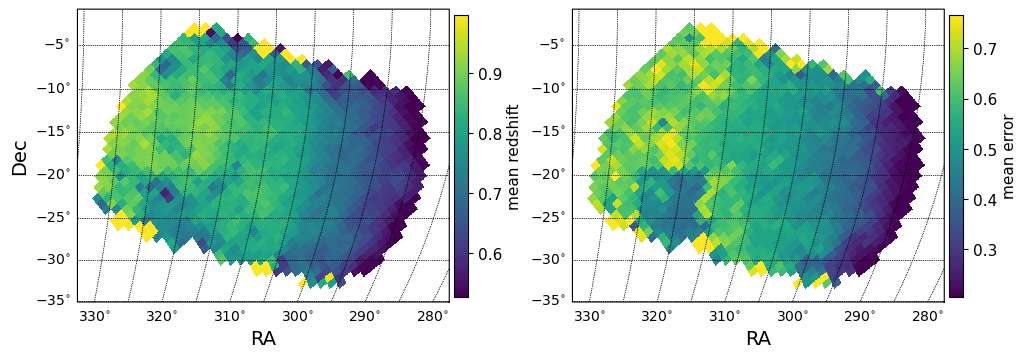

</div>

In [ ]:
del hspmap_maglim, hspmap_cov, cov_pixels, pixels
gc.collect()

In [ ]:
client.close()
del client
gc.collect()